# Set-up

In [1]:
# Set-Up and load data
import session_info
from pathlib import Path
import celltypist
import pandas as pd
import matplotlib.pyplot as plt
import dotools_py as do
from dotools_py.pp._importer import _qc_vln


data_path = Path('/Volumes/Zmm_shared/David/Papers/dotools/Objects')
figure_path = Path('/Users/david/Downloads/Manuscript')

adata = do.io.read_h5ad(data_path / 'adata.h5ad')

2026-01-21 15:01:08,957 - Jupyter enviroment detected. Using "inline" backend


# Figure 1 - Workflow of DoTools

In [2]:
# Figure 1A - ViolinPlots of QC metrics
_qc_vln(adata, title='', path=figure_path, filename='Figure1A_ViolinPlot_QCMetrics.svg')

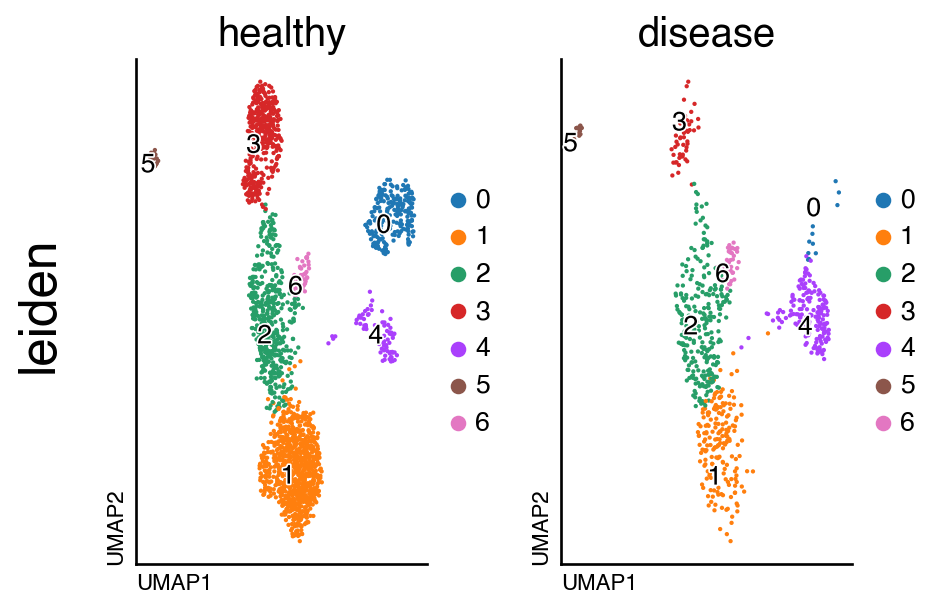

<Figure size 320x400 with 0 Axes>

In [3]:
# Figure 1B - UMAP splitting by condition
do.pl.umap(
    adata, 'leiden', split_by='condition', labels='leiden', path=figure_path, filename='Figure1B_UMAP_SplittingCondition.svg', figsize=(6, 4), size=15
)

🔬 Input data has 2801 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 3323 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


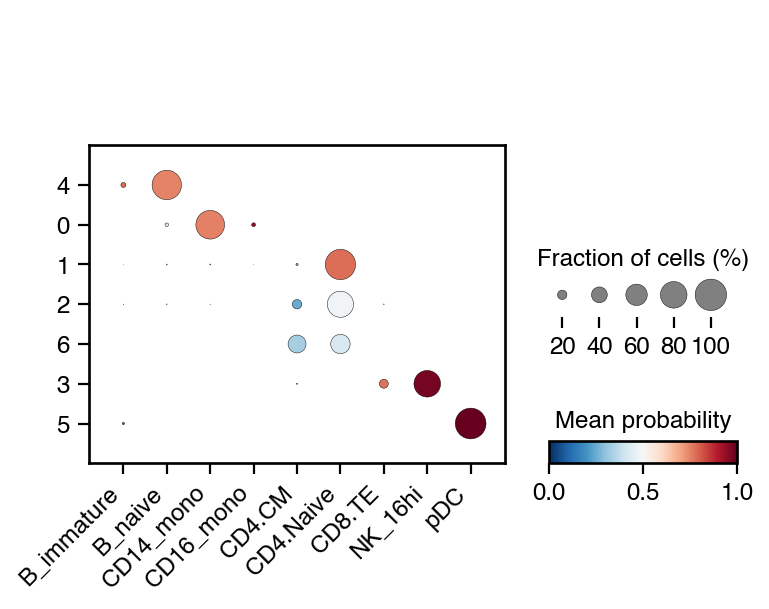

In [4]:
# Figure 1B - Celltypist Probability Dotplot
model_loaded = celltypist.models.Model.load(model="Healthy_COVID19_PBMC.pkl")
adata_copy = adata.copy()
adata_copy.X = adata_copy.X.toarray()
pred = celltypist.annotate(adata_copy, model=model_loaded, majority_voting=False, over_clustering="leiden")
spred = pred.to_adata()

# Only visualize  a subset of cell type
spred = spred[spred.obs.predicted_labels.isin(["B_naive", "B_immature", "CD14_mono", "CD16_mono", "CD4.Naive", "CD4.CM", "CD8.TE", "NK_16hi", "pDC"])]

# Correct the object
pred.adata = spred
pred.decision_matrix = pred.decision_matrix[pred.decision_matrix.index.isin(list(spred.obs_names))]
pred.decision_matrix = pred.decision_matrix[[ "B_naive", "B_immature", "CD14_mono", "CD16_mono", "CD4.Naive", "CD4.CM", "CD8.TE", "NK_16hi", "pDC"]]

pred.predicted_labels = pred.predicted_labels[pred.predicted_labels.index.isin(list(spred.obs_names))]
pred.probability_matrix = pred.probability_matrix[pred.probability_matrix.index.isin(list(spred.obs_names))]
pred.probability_matrix = pred.probability_matrix[[ "B_naive", "B_immature", "CD14_mono", "CD16_mono", "CD4.Naive", "CD4.CM", "CD8.TE", "NK_16hi", "pDC"]]
pred.cell_count = 1960
pred.predicted_labels['predicted_labels'] = pd.Categorical(pred.predicted_labels['predicted_labels'].astype(str))

fig, axs = plt.subplots(1, 1, figsize=(5, 4))
axs = celltypist.dotplot(pred, use_as_prediction="predicted_labels", use_as_reference="leiden", title="",
                         show=False, ax=axs, swap_axes=True)
axs["mainplot_ax"].spines[["top", "right"]].set_visible(True)
axs["mainplot_ax"].set_xticklabels(axs["mainplot_ax"].get_xticklabels(), fontweight='bold', rotation=45, ha='right', va='top')
plt.savefig( figure_path / 'Figure1B_DotplotCelltypist.svg', bbox_inches="tight")

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.13 seconds
2026-01-21 15:01:14,593 - There are 5 populations with a significant change


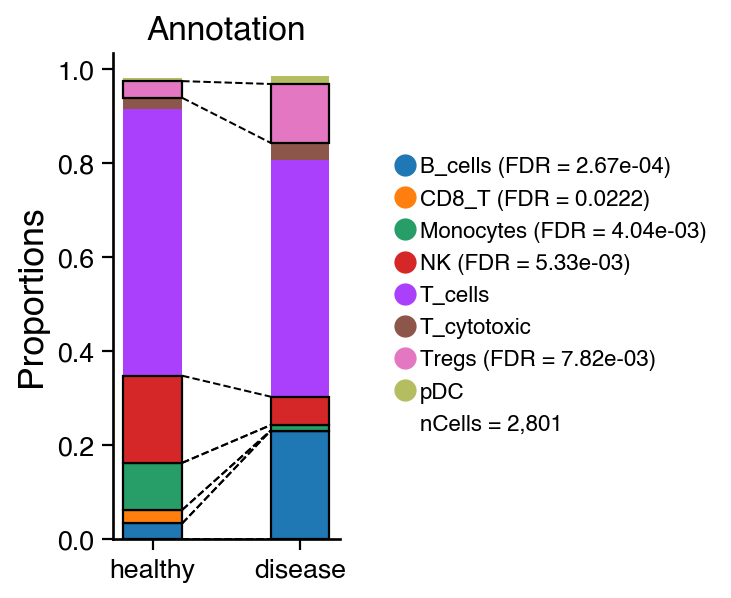

In [5]:
# Figure 1B - Barplot cell proportions
do.pl.cell_composition(
    adata, 'annotation_recluster', 'condition', 'batch', transform='arcsin', figsize=(3.5, 4), condition_order=['healthy', 'disease'], legend_fontproperties={"size": 10, "weight": "bold"}, title="Annotation", path=figure_path, filename="Figure1B_CellProportions.svg"
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be i

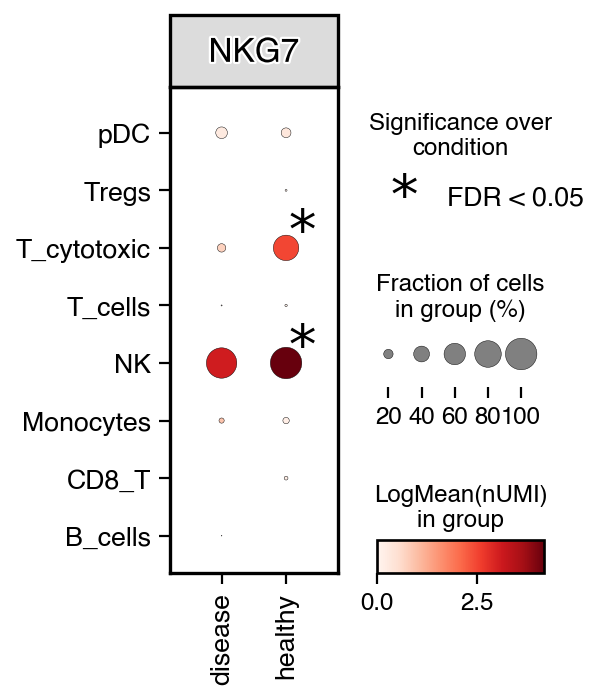

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be i

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


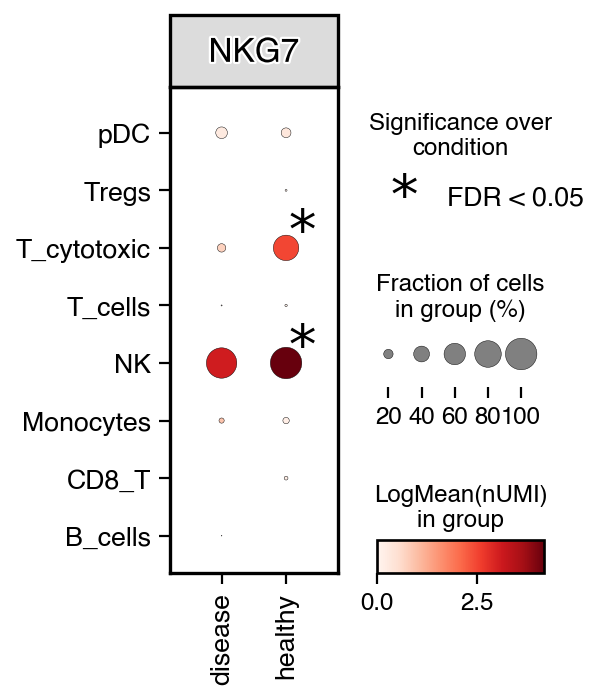

In [6]:
# Figure 1C - 3D Dotplot
do.pl.dotplot(
    adata, 'condition', 'NKG7', 'annotation_recluster', add_stats='x_axis', figsize=(3, 4), path=figure_path, filename='Figure1C_3Dotplot_AnnotationCondition.svg',
)
do.pl.dotplot(
    adata, 'condition', 'NKG7', 'annotation_recluster', add_stats='x_axis', figsize=(3, 4), path=figure_path, filename='Figure1C_3Dotplot_AnnotationCondition.pdf',
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


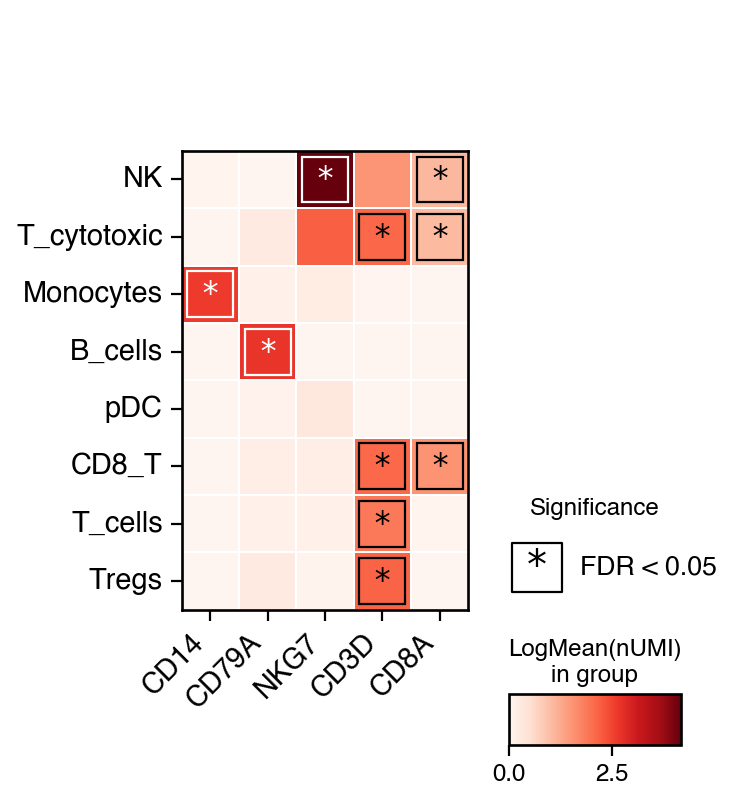

In [7]:
# Figure 1C - Heatmap
do.pl.heatmap(
    adata, 'annotation_recluster', ['CD14', 'CD3D', 'CD79A', 'CD8A', 'NKG7'], xticks_rotation=45, figsize=(4, 6), add_stats=True, cluster_x_axis=True, cluster_y_axis=True,
    path=figure_path, filename='Figure1C_Heatmap.svg', stats_x_size=18,
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


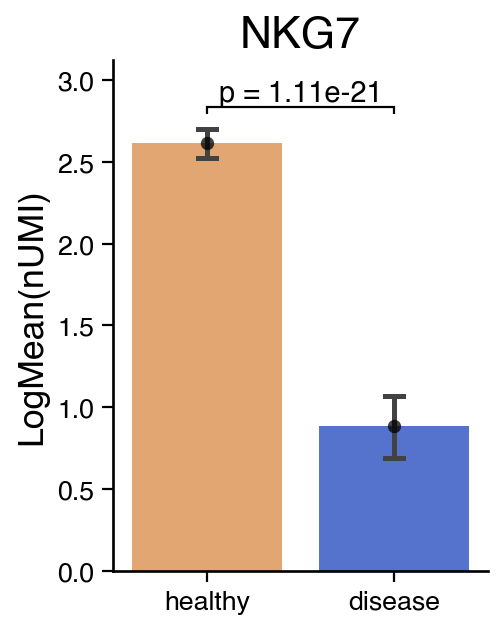

In [8]:
# Figure 1C - Barplot NKG7
do.pl.barplot(
    adata, 'condition', 'NKG7', reference='healthy', groups=['disease'], palette={'healthy': 'sandybrown', 'disease':'royalblue'}, path=figure_path,
    filename='Figure1C_BarplotNKG7.svg'
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
2026-01-21 15:01:21,955 - Running GSA on Up- and Down-regulated genes
2026-01-21 15:02:48,456 - !!! Assuming GO Terms are preprocessed (Only Significant terms included)


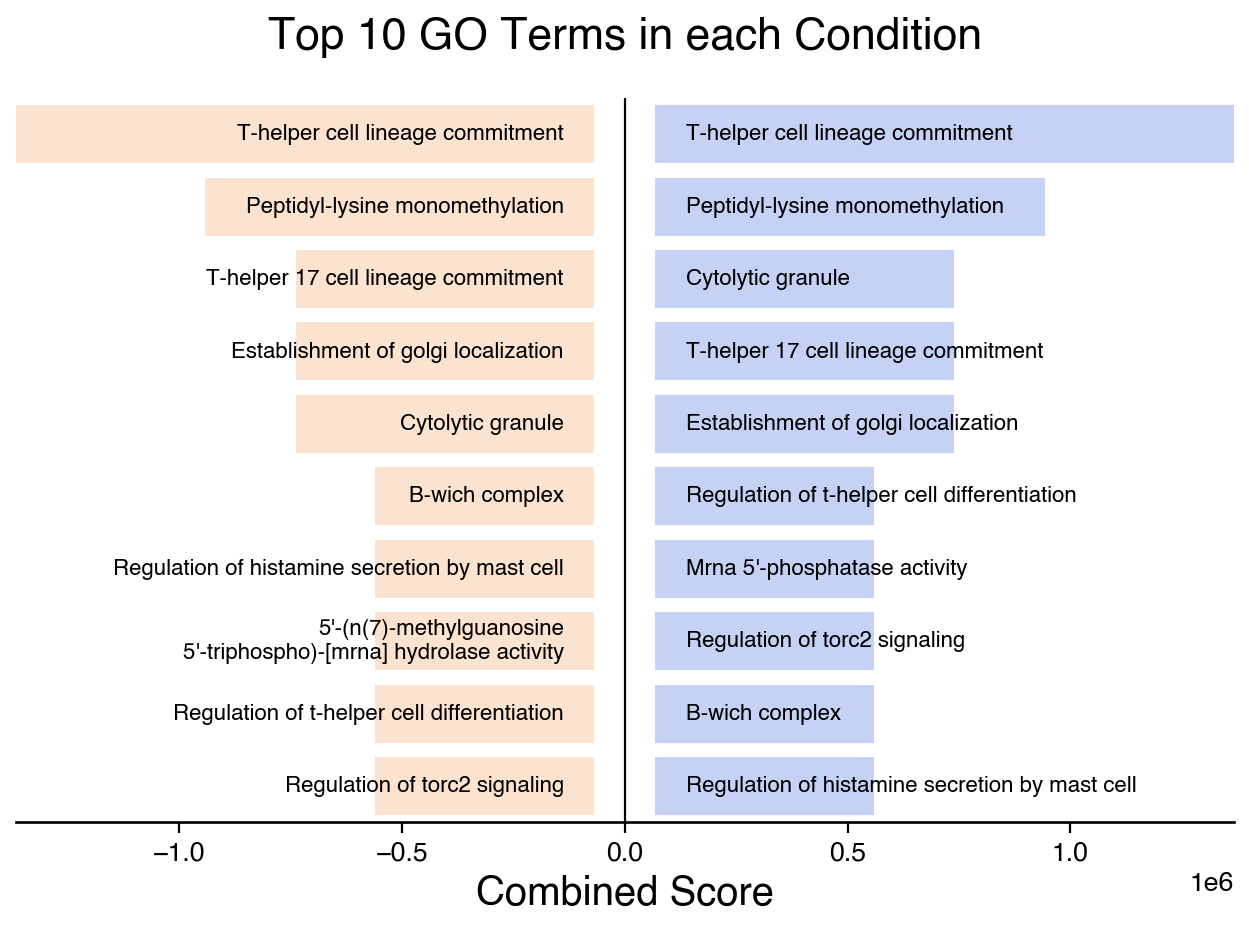

In [9]:
# Figure 1C - Split bar GSEA
do.tl.rank_genes_groups(adata, groupby='condition')
table = do.get.dge_results(adata)
df = do.tl.go_analysis(table, gene_key='GeneName', pval_key='padj', log2fc_key='log2fc')
df = df[df['Adjusted P-value'] < 0.05]
df["Term"] = df["Term"].str.split(" \(GO").str[0]
do.pl.split_bar_gsea(
    df, 'Term',  'Combined Score', 'state', 'enriched', figsize=(8, 6), path=figure_path, filename='Figure1C_SplitGSEA.svg', txt_size=10,
)

ranking genes
--> Few observations in a group for normal approximation (<=25). Lower test accuracy.
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted n

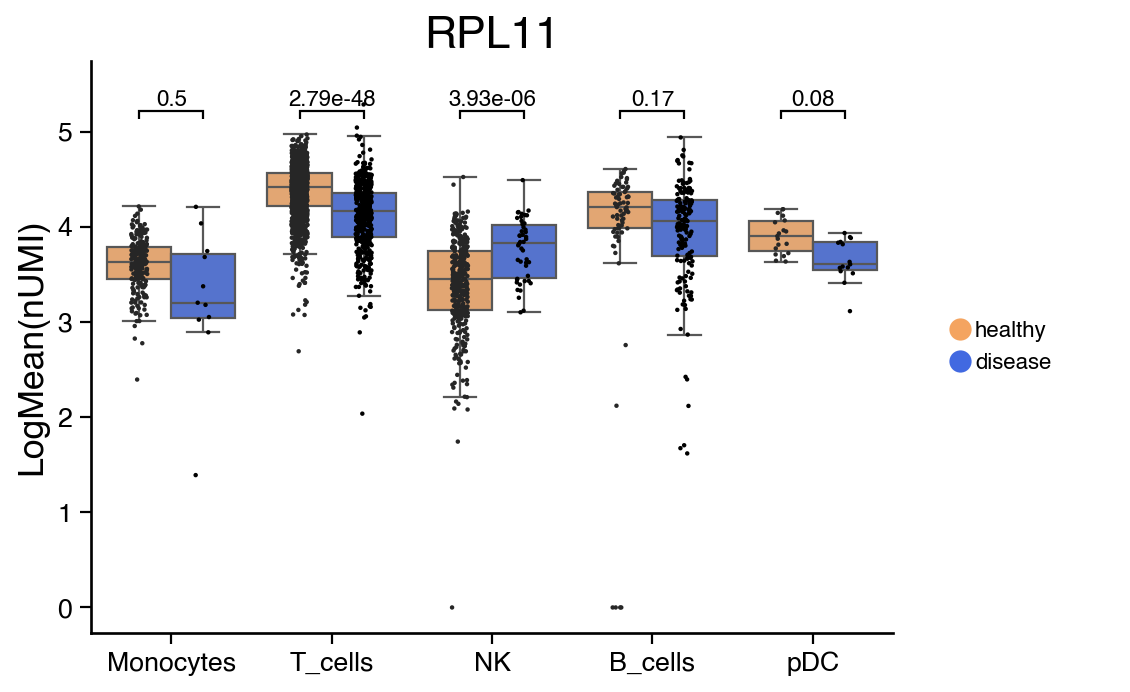

In [10]:
# Figure 1C - Split Boxplot RPL11
do.pl.boxplot(
    adata, "annotation", "RPL11", hue="condition", figsize=(8.2, 4.7), palette={"healthy":'sandybrown', "disease":"royalblue"}, txt_size=10, txt="",
    reference='healthy', groups=['disease'], hue_order=['healthy', 'disease'], path=figure_path, filename='Figure1C_Boxplot_GeneAnnotationHueCondition.svg'
)

# Figure 2 - Visualisation examples

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
2026-01-21 15:02:50,233 - Running GSA on Up- and Down-regulated genes
2026-01-21 15:04:22,567 - !!! Assuming GO Terms are preprocessed (Only Significant terms included)


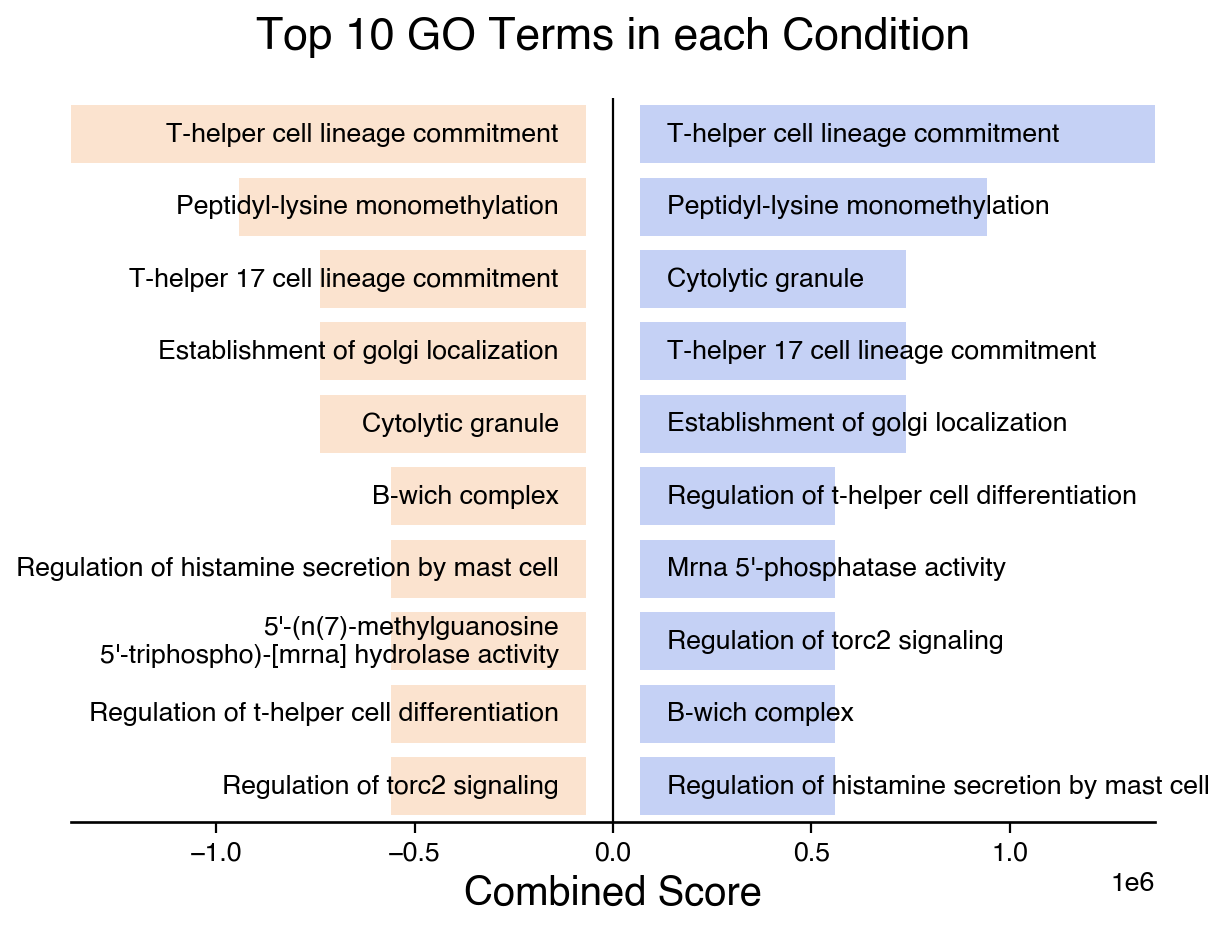

In [11]:
# Figure 2 - Split bar GSEA readable
do.tl.rank_genes_groups(adata, groupby='condition')
table = do.get.dge_results(adata)
df = do.tl.go_analysis(table, gene_key='GeneName', pval_key='padj', log2fc_key='log2fc')
df = df[df['Adjusted P-value'] < 0.05]
df["Term"] = df["Term"].str.split(" \(GO").str[0]
do.pl.split_bar_gsea(
    df, 'Term',  'Combined Score', 'state', 'enriched', figsize=(8, 6), path=figure_path, filename='Figure2G_SplitGSEA.svg'
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


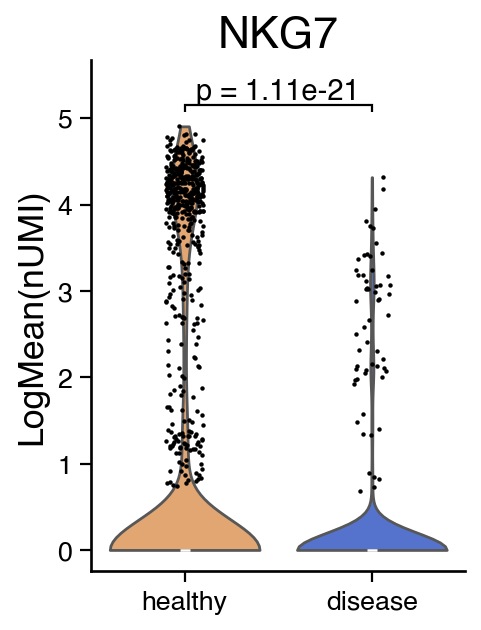

In [12]:
# Figure 2C - ViolinPlot
do.pl.violinplot(
    adata, 'condition', 'NKG7', reference='healthy', groups=['disease'], palette={'healthy': 'sandybrown', 'disease':'royalblue'}, path=figure_path,
    filename='Figure2C_ViolinNKG7.svg', scatter=True, figsize=(3, 4.2)
)

# Session Information

In [13]:
session_info.show(na=False, cpu=True, excludes=["backports"], std_lib=True, dependencies=True, html=True)

In [14]:
import platform
import psutil

print("OS:", platform.platform())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("CPU cores (physical):", psutil.cpu_count(logical=False))
print("CPU cores (logical):", psutil.cpu_count(logical=True))
print("Total RAM (GB):", round(psutil.virtual_memory().total / (1024 ** 3), 2))
print("Python version:", platform.python_version())

OS: macOS-26.2-arm64-arm-64bit
Machine: arm64
Processor: arm
CPU cores (physical): 10
CPU cores (logical): 10
Total RAM (GB): 16.0
Python version: 3.11.13
